,class,count
10,Excel,75
11,Query,72
4,Data Flow Object,44
9,DTP,42
8,Datenvorschau,41
12,Transformationen,39
2,BW4Cockpit (Stammdaten),38
0,ABAP Dictionary,33
6,Data Source,28
3,Composite Provider,17


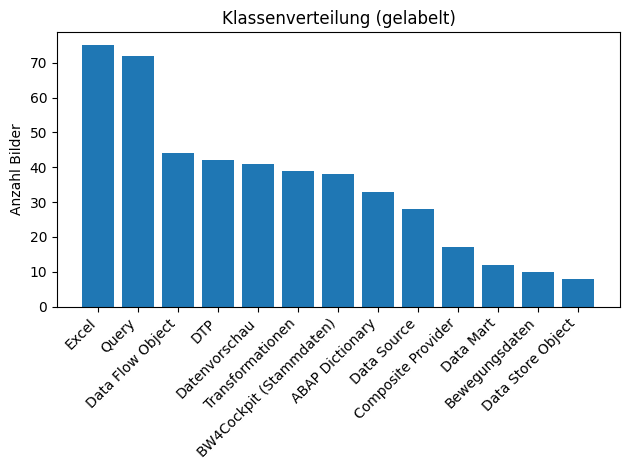

In [74]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "Data"
LABELED_DIR = DATA_DIR / "SAP Bilder sortiert"

def is_image(p: Path):
    return p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".webp",".tif",".tiff"}

rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df)

plt.figure()
plt.bar(df["class"], df["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt)")
plt.tight_layout()
plt.show()

In [75]:
DATA_DIR = Path("..") / "Data"
LABELED_DIR = DATA_DIR / "SAP Bilder sortiert"

def is_image(p: Path):
    return p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".webp",".tif",".tiff"}

counts = {}
for cls_dir in LABELED_DIR.iterdir():
    if cls_dir.is_dir():
        counts[cls_dir.name] = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))

s = pd.Series(counts).sort_values(ascending=False)
print("Counts:\n", s)

cap = 75
target = 50

downsample = (s - cap).clip(lower=0).astype(int)      # wie viele entfernen
topup      = (target - s).clip(lower=0).astype(int)   # wie viele ergänzen

print("\nDownsample (remove):\n", downsample[downsample>0])
print("\nUnderrepresented vs target\n", topup[topup>0])
print("\nTotal missing to reach target:", int(topup.sum()))

Counts:
 Excel                      75
Query                      72
Data Flow Object           44
DTP                        42
Datenvorschau              41
Transformationen           39
BW4Cockpit (Stammdaten)    38
ABAP Dictionary            33
Data Source                28
Composite Provider         17
Data Mart                  12
Bewegungsdaten             10
Data Store Object           8
dtype: int64

Downsample (remove):
 Series([], dtype: int64)

Underrepresented vs target
 Data Flow Object            6
DTP                         8
Datenvorschau               9
Transformationen           11
BW4Cockpit (Stammdaten)    12
ABAP Dictionary            17
Data Source                22
Composite Provider         33
Data Mart                  38
Bewegungsdaten             40
Data Store Object          42
dtype: int64

Total missing to reach target: 238


In [76]:
import random
WORK_DIR = Path("..") / "Work"
REDUCED_DIR = WORK_DIR / "reduced"
REDUCED_DIR.mkdir(parents=True, exist_ok=True)

seed = 42
rng = random.Random(seed)

# downsample kommt aus deiner Zelle 2
# downsample['Excel'] = 57 (Beispiel)

def move_random_images(cls_name: str, n_remove: int):
    src_dir = LABELED_DIR / cls_name
    if not src_dir.exists():
        print(f"[WARN] Klasse nicht gefunden: {cls_name}")
        return 0

    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image(p)]
    if n_remove <= 0:
        return 0

    rng.shuffle(imgs)
    to_move = imgs[:min(n_remove, len(imgs))]

    dst_dir = REDUCED_DIR / cls_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    for p in to_move:
        shutil.move(str(p), str(dst_dir / p.name))

    return len(to_move)

removed_total = 0
for cls_name, n_remove in downsample.items():
    n_remove = int(n_remove)
    if n_remove > 0:
        moved = move_random_images(cls_name, n_remove)
        removed_total += moved
        print(f"Reduced {cls_name}: moved {moved} images to {REDUCED_DIR/cls_name}")

print("Total moved:", removed_total)

Total moved: 0


In [77]:
#TODO nicht unbedingt notwendig wenn wir die Daten manuel gelabeled haben
import random

UNLABELED_DIR = DATA_DIR / "Ungelabelt"
SPLITS_DIR = DATA_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

def list_images(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])

unlabeled_all = list_images(UNLABELED_DIR)
print("Unlabeled total:", len(unlabeled_all))

holdout_ratio = 0.50 # mindestens 50% reservieren
seed = 42
rng = random.Random(seed)

idx = list(range(len(unlabeled_all)))
rng.shuffle(idx)

holdout_n = int(len(unlabeled_all) * holdout_ratio)
holdout_idx = set(idx[:holdout_n])

unlabeled_holdout = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i in holdout_idx]
unlabeled_candidate = [unlabeled_all[i] for i in range(len(unlabeled_all)) if i not in holdout_idx]

print("Holdout:", len(unlabeled_holdout))
print("Candidate:", len(unlabeled_candidate))

pd.DataFrame({"path": [str(p) for p in unlabeled_holdout]}).to_csv(SPLITS_DIR / "unlabeled_holdout.csv", index=False)
pd.DataFrame({"path": [str(p) for p in unlabeled_candidate]}).to_csv(SPLITS_DIR / "unlabeled_candidate.csv", index=False)

Unlabeled total: 3135
Holdout: 1567
Candidate: 1568


In [78]:
#Train/Val
import shutil
import random

WORK_DIR = Path("..") / "Work"
SPLIT_DIR = WORK_DIR / "datasets" / "base_split"
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

# optional: bestehenden Split neu bauen
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

val_ratio = 0.2
seed = 42
rng = random.Random(seed)

def safe_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)

for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    cls = cls_dir.name
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and is_image(p)]
    rng.shuffle(imgs)
    n_val = max(1, int(len(imgs) * val_ratio)) if len(imgs) > 0 else 0

    val_imgs = imgs[:n_val]
    train_imgs = imgs[n_val:]

    for p in train_imgs:
        safe_copy(p, TRAIN_DIR / cls / p.name)
    for p in val_imgs:
        safe_copy(p, VAL_DIR / cls / p.name)

print("Split erstellt:", SPLIT_DIR)


Split erstellt: ..\Work\datasets\base_split


In [79]:
#Yolo Baslines
from ultralytics import YOLO

# Untrainiert (random weights) -> Referenz
yolo_untrained = YOLO("yolov8n-cls.yaml")
m0 = yolo_untrained.val(data=str(SPLIT_DIR))
print("YOLO untrained baseline:", m0)

# Pretrained (ImageNet) ohne Fine-Tuning -> Ausgangsmodell
yolo_pre = YOLO("yolov8n-cls.pt")
m1 = yolo_pre.val(data=str(SPLIT_DIR))
print("YOLO pretrained (no finetune):", m1)

YOLOv8n-cls summary: 56 layers, 2,719,288 parameters, 2,719,288 gradients, 4.4 GFLOPs
Ultralytics 8.3.239  Python-3.12.10 torch-2.9.1+cpu CPU (AMD Ryzen 7 9800X3D 8-Core Processor)
YOLOv8n-cls summary (fused): 30 layers, 2,715,880 parameters, 1,281,000 gradients, 4.3 GFLOPs
train: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\train... found 373 images in 13 classes  
val: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... found 86 images in 13 classes  
test: None...
val: Fast image access  (ping: 0.00.0 ms, read: 39.315.3 MB/s, size: 48.5 KB)
val: Scanning C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... 86 images, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 1.8Kit/s 0.0s
val: New cache created: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.1s0.6ss
                   all          0          0
Speed: 0.0ms p

In [80]:
#Yolo Training
yolo_model = YOLO("yolov8n-cls.pt")

yolo_model.train(
    data=str(SPLIT_DIR),
    imgsz=224,
    epochs=20,
    batch=32,
    workers=2
    # device=0  # optional: wenn GPU sicher da ist, sonst weglassen
)

Ultralytics 8.3.239  Python-3.12.10 torch-2.9.1+cpu CPU (AMD Ryzen 7 9800X3D 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Work\datasets\base_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000021614664050>
curves: []
curves_results: []
fitness: 0.947674423456192
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9186046719551086, 'metrics/accuracy_top5': 0.9767441749572754, 'fitness': 0.947674423456192}
save_dir: WindowsPath('C:/Users/morit/Documents/Python/Data-Science/src/runs/classify/train5')
speed: {'preprocess': 0.0004988369466953499, 'inference': 1.0587767451503423, 'loss': 2.558159013820249e-05, 'postprocess': 5.00003807246685e-05}
task: 'classify'
top1: 0.9186046719551086
top5: 0.9767441749572754

In [81]:
# Yolo Validation
m2 = yolo_model.val(data=str(SPLIT_DIR))
print("YOLO finetuned:", m2)

Ultralytics 8.3.239  Python-3.12.10 torch-2.9.1+cpu CPU (AMD Ryzen 7 9800X3D 8-Core Processor)
YOLOv8n-cls summary (fused): 30 layers, 1,451,533 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\train... found 373 images in 13 classes  
val: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... found 86 images in 13 classes  
test: None...
val: Fast image access  (ping: 0.00.0 ms, read: 88.934.8 MB/s, size: 48.5 KB)
val: Scanning C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... 86 images, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86  0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 5.1it/s 1.2s0.2s
                   all      0.919      0.977
Speed: 0.0ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\morit\Documents\Python\Data-Science\src\runs\classify\val17
YOLO finetuned: ultralytics.utils.metrics.ClassifyMet

In [82]:
import ultralytics
print("ultralytics version:", ultralytics.__version__)

ultralytics version: 8.3.239


In [83]:
#ResNet
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [84]:
# Pretrained weights + passende Standard-Transforms
weights = models.ResNet18_Weights.IMAGENET1K_V1
val_tf = weights.transforms()  # enthält resize/crop + normalize

# Train-Transforms: leichte Augmentation + gleiche Normalisierung
# (Mean/Std aus weights.transforms() übernehmen)
mean = weights.transforms().mean
std  = weights.transforms().std

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(str(VAL_DIR), transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

class_names = train_ds.classes
n_classes = len(class_names)

print("Klassen (ImageFolder-Reihenfolge):", class_names)
print("n_classes:", n_classes)

Klassen (ImageFolder-Reihenfolge): ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
n_classes: 13


In [85]:
def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc

# Baseline A: komplett untrainiert (random weights)
resnet_untrained = models.resnet18(weights=None)
resnet_untrained.fc = nn.Linear(resnet_untrained.fc.in_features, n_classes)
resnet_untrained.to(device)

y_true, y_pred, acc = eval_model(resnet_untrained, val_loader)
print("RESNET untrained baseline acc:", acc)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Baseline B: pretrained backbone (ImageNet), aber neuer (untrainierter) Klassifikationskopf
resnet_pre = models.resnet18(weights=weights)
resnet_pre.fc = nn.Linear(resnet_pre.fc.in_features, n_classes)
resnet_pre.to(device)

y_true, y_pred, acc = eval_model(resnet_pre, val_loader)
print("RESNET pretrained (no finetune) acc:", acc)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

RESNET untrained baseline acc: 0.09302325581395349
                         precision    recall  f1-score   support

        ABAP Dictionary       0.00      0.00      0.00         6
BW4Cockpit (Stammdaten)       0.00      0.00      0.00         7
         Bewegungsdaten       0.00      0.00      0.00         2
     Composite Provider       0.00      0.00      0.00         3
                    DTP       0.09      1.00      0.17         8
       Data Flow Object       0.00      0.00      0.00         8
              Data Mart       0.00      0.00      0.00         2
            Data Source       0.00      0.00      0.00         5
      Data Store Object       0.00      0.00      0.00         1
          Datenvorschau       0.00      0.00      0.00         8
                  Excel       0.00      0.00      0.00        15
                  Query       0.00      0.00      0.00        14
       Transformationen       0.00      0.00      0.00         7

               accuracy              

In [86]:
WORK_DIR = Path("..") / "Work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

CKPT = WORK_DIR / "resnet18_best.pt"
HIST = WORK_DIR / "resnet18_history.csv"

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

def train_one_epoch(model):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(train_loader.dataset)

best_acc = 0.0
history = []

epochs = 10
for epoch in range(1, epochs + 1):
    loss = train_one_epoch(model)
    y_true, y_pred, val_acc = eval_model(model, val_loader)
    print(f"Epoch {epoch:02d} | loss={loss:.4f} | val_acc={val_acc:.4f}")

    history.append({"epoch": epoch, "train_loss": loss, "val_acc": val_acc})
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CKPT)

pd.DataFrame(history).to_csv(HIST, index=False)
print("Best val_acc:", best_acc)
print("Saved:", CKPT)
print("Saved:", HIST)

Epoch 01 | loss=1.3182 | val_acc=0.7209
Epoch 02 | loss=0.2965 | val_acc=0.8605
Epoch 03 | loss=0.0994 | val_acc=0.9419
Epoch 04 | loss=0.0447 | val_acc=0.9070
Epoch 05 | loss=0.0350 | val_acc=0.9419
Epoch 06 | loss=0.0285 | val_acc=0.9186
Epoch 07 | loss=0.0265 | val_acc=0.9302
Epoch 08 | loss=0.0179 | val_acc=0.9186
Epoch 09 | loss=0.0067 | val_acc=0.9419
Epoch 10 | loss=0.0146 | val_acc=0.9302
Best val_acc: 0.9418604651162791
Saved: ..\Work\resnet18_best.pt
Saved: ..\Work\resnet18_history.csv


RESNET finetuned acc: 0.9418604651162791
                         precision    recall  f1-score   support

        ABAP Dictionary       0.86      1.00      0.92         6
BW4Cockpit (Stammdaten)       1.00      0.86      0.92         7
         Bewegungsdaten       1.00      1.00      1.00         2
     Composite Provider       1.00      1.00      1.00         3
                    DTP       1.00      0.88      0.93         8
       Data Flow Object       1.00      1.00      1.00         8
              Data Mart       0.00      0.00      0.00         2
            Data Source       0.83      1.00      0.91         5
      Data Store Object       0.50      1.00      0.67         1
          Datenvorschau       0.88      0.88      0.88         8
                  Excel       1.00      1.00      1.00        15
                  Query       0.93      1.00      0.97        14
       Transformationen       1.00      1.00      1.00         7

               accuracy                        

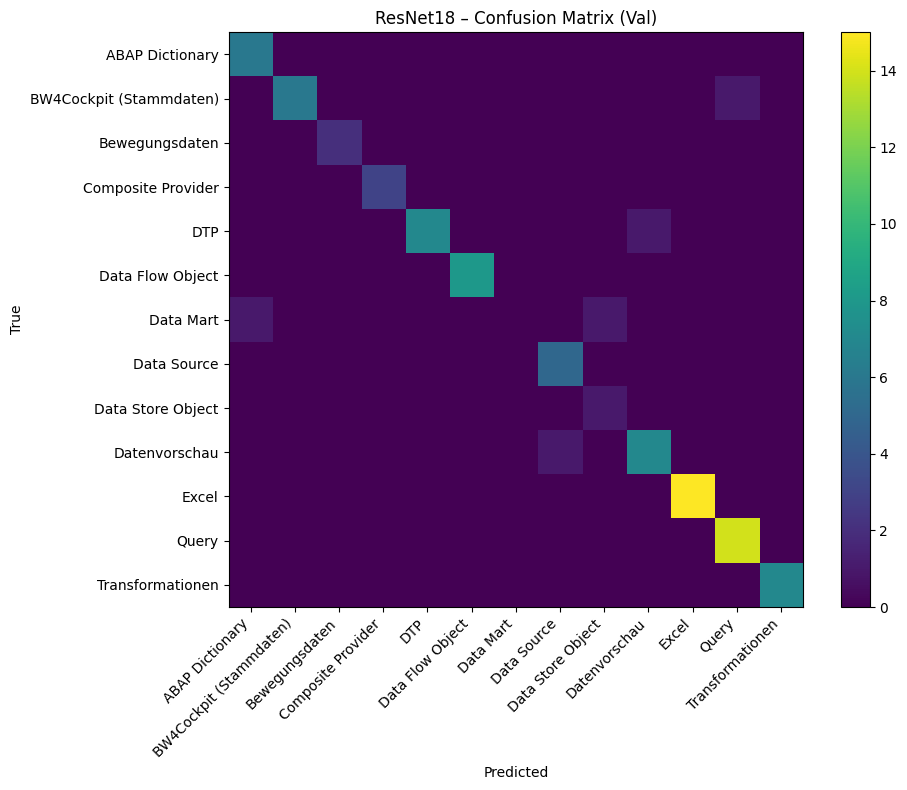

In [87]:
# Bestes Modell laden
model.load_state_dict(torch.load(CKPT, map_location=device))

y_true, y_pred, acc = eval_model(model, val_loader)
print("RESNET finetuned acc:", acc)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Confusion Matrix plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("ResNet18 – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

In [88]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ---------- Val-Set als (paths, y_true) laden ----------
def get_val_paths_labels(val_dir: Path):
    class_names = sorted([d.name for d in val_dir.iterdir() if d.is_dir()])
    class_to_idx = {c:i for i,c in enumerate(class_names)}
    paths, y_true = [], []
    for c in class_names:
        for p in (val_dir / c).iterdir():
            if p.is_file() and is_image(p):
                paths.append(p)
                y_true.append(class_to_idx[c])
    return paths, np.array(y_true), class_names, class_to_idx

val_paths, y_true_val, class_names_val, class_to_idx_val = get_val_paths_labels(VAL_DIR)
print("VAL samples:", len(val_paths))
print("VAL classes:", class_names_val)


# ---------- Helper: aus sklearn report Kennzahlen ziehen ----------
def summarize_sklearn(y_true, y_pred, class_names):
    rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    return {
        "accuracy": float(rep["accuracy"]),
        "macro_f1": float(rep["macro avg"]["f1-score"]),
        "weighted_f1": float(rep["weighted avg"]["f1-score"]),
        "report": rep
    }


# ---------- YOLO: Accuracy aus val()-Objekt robust extrahieren ----------
def yolo_val_top1(yolo_model, split_dir: Path):
    m = yolo_model.val(data=str(split_dir), verbose=False)

    # Je nach Ultralytics-Version heißen Felder leicht anders -> robust versuchen
    for attr in ["top1", "acc", "accuracy"]:
        if hasattr(m, attr):
            return float(getattr(m, attr)), m

    # Manchmal steckt es in einem dict/metrics Feld
    for attr in ["results_dict", "metrics", "speed"]:
        if hasattr(m, attr):
            obj = getattr(m, attr)
            if isinstance(obj, dict):
                for k in ["top1", "acc", "accuracy", "metrics/top1", "metrics/accuracy_top1"]:
                    if k in obj:
                        return float(obj[k]), m

    # Fallback: unbekannt
    return np.nan, m


# ---------- YOLO: optional F1 via predict() (nur wenn es funktioniert) ----------
def yolo_predict_f1_safe(yolo_model, paths, y_true, class_names, class_to_idx, batch=64):
    try:
        names = yolo_model.names
        idx_to_name = {int(k): v for k, v in names.items()} if isinstance(names, dict) else {i:n for i,n in enumerate(names)}

        y_pred = np.empty(len(paths), dtype=int)
        for start in range(0, len(paths), batch):
            chunk = paths[start:start+batch]
            results = yolo_model.predict(source=[str(p) for p in chunk], verbose=False)
            for i, r in enumerate(results):
                pred_idx = int(r.probs.top1)
                pred_class = idx_to_name[pred_idx]
                if pred_class not in class_to_idx:
                    raise ValueError(f"YOLO pred_class '{pred_class}' nicht in VAL Klassen.")
                y_pred[start+i] = class_to_idx[pred_class]

        return summarize_sklearn(y_true, y_pred, class_names), y_pred

    except AttributeError as e:
        # genau dein Fehlerfall: transforms fehlen
        print("[INFO] YOLO predict() nicht möglich für dieses Modell:", e)
        return None, None


# ---------- RESNET: nutzt dein eval_model(model, val_loader) ----------
def resnet_metrics(model, val_loader, class_names):
    y_true, y_pred, _acc = eval_model(model, val_loader)
    out = summarize_sklearn(y_true, y_pred, class_names)
    return out, y_true, y_pred


rows = []

# YOLO Modelle: Accuracy aus val(), F1 nur optional (hier: nur finetuned versuchen)
for name, mdl, do_f1 in [
    ("YOLO untrained (yolov8n-cls.yaml)", yolo_untrained, False),
    ("YOLO pretrained (no finetune)",     yolo_pre,       False),
    ("YOLO finetuned",                    yolo_model,     True),
]:
    top1, mobj = yolo_val_top1(mdl, SPLIT_DIR)

    macro_f1 = np.nan
    weighted_f1 = np.nan
    y_pred_yolo = None

    if do_f1:
        f1_out, y_pred_yolo = yolo_predict_f1_safe(mdl, val_paths, y_true_val, class_names_val, class_to_idx_val, batch=64)
        if f1_out is not None:
            macro_f1 = f1_out["macro_f1"]
            weighted_f1 = f1_out["weighted_f1"]

    rows.append({
        "model": name,
        "val_samples": len(y_true_val),
        "accuracy_top1": top1,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

# ResNet Modelle: Accuracy + F1 immer verfügbar
for name, mdl in [
    ("ResNet18 untrained",                resnet_untrained),
    ("ResNet18 pretrained (no finetune)", resnet_pre),
    ("ResNet18 finetuned",                model),
]:
    out, ytr, ypr = resnet_metrics(mdl, val_loader, class_names_val)
    rows.append({
        "model": name,
        "val_samples": len(ytr),
        "accuracy_top1": out["accuracy"],
        "macro_f1": out["macro_f1"],
        "weighted_f1": out["weighted_f1"]
    })

compare_df = pd.DataFrame(rows).sort_values(["macro_f1", "accuracy_top1"], ascending=False)
display(compare_df)

OUT_CSV = Path("..") / "Work" / "model_comparison.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
compare_df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

VAL samples: 86
VAL classes: ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
Ultralytics 8.3.239  Python-3.12.10 torch-2.9.1+cpu CPU (AMD Ryzen 7 9800X3D 8-Core Processor)
train: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\train... found 373 images in 13 classes  
val: C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... found 86 images in 13 classes  
test: None...
val: Fast image access  (ping: 0.00.0 ms, read: 115.346.9 MB/s, size: 48.5 KB)
val: Scanning C:\Users\morit\Documents\Python\Data-Science\Work\datasets\base_split\val... 86 images, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 57.2Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 6/6 2.6it/s 2.3s0.5s
                   all          0          0
Speed: 0.0ms preprocess, 9.6ms inference, 0.0ms lo

,model,val_samples,accuracy_top1,macro_f1,weighted_f1
2,YOLO finetuned,86,0.918605,0.868244,0.918084
5,ResNet18 finetuned,86,0.941860,0.861212,0.932512
4,ResNet18 pretrained (no finetune),86,0.081395,0.055811,0.055754
3,ResNet18 untrained,86,0.093023,0.013093,0.015834
0,YOLO untrained (yolov8n-cls.yaml),86,0.000000,NaN,NaN
1,YOLO pretrained (no finetune),86,0.000000,NaN,NaN


Saved: ..\Work\model_comparison.csv


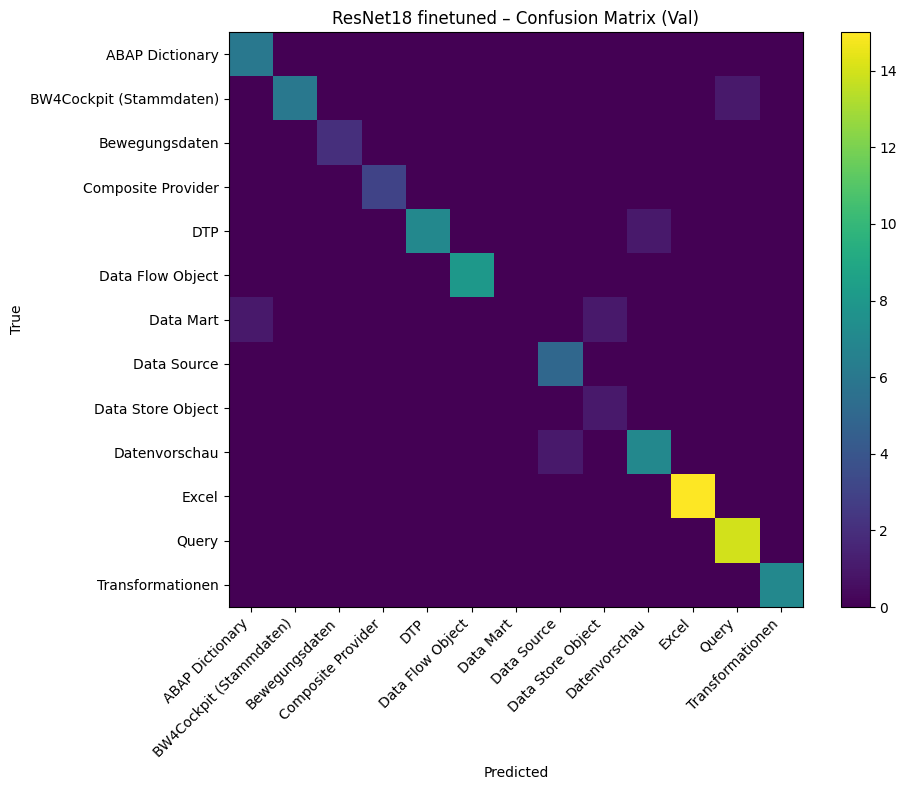

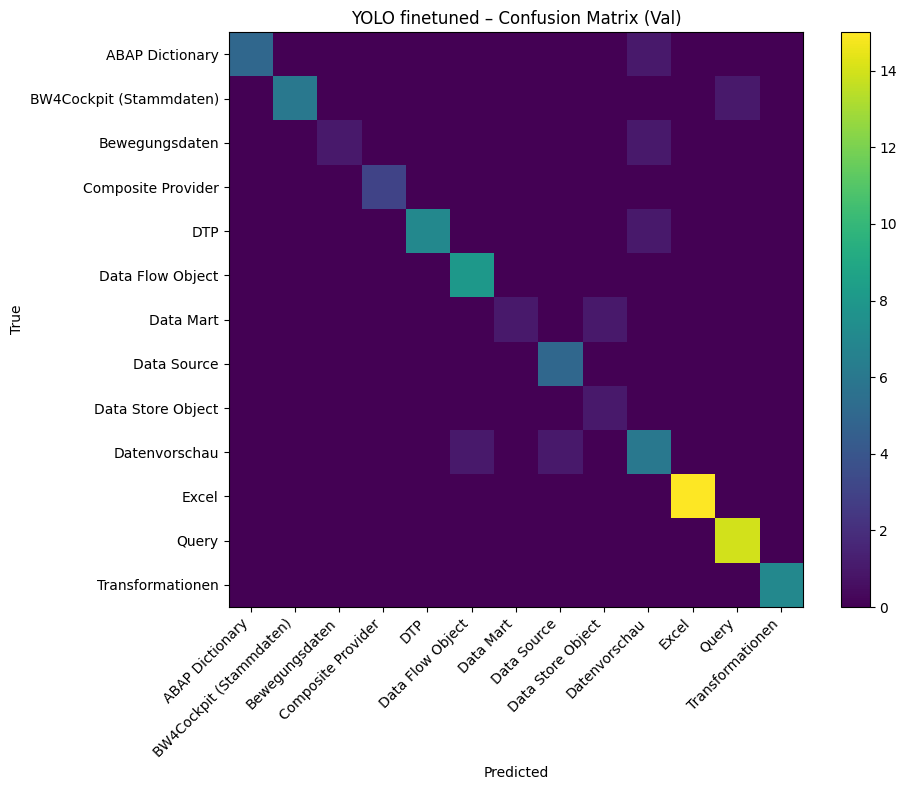

In [89]:
from sklearn.metrics import confusion_matrix

def plot_cm(cm, class_names, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ResNet finetuned CM
out_res, ytr_res, ypr_res = resnet_metrics(model, val_loader, class_names_val)
plot_cm(confusion_matrix(ytr_res, ypr_res), class_names_val, "ResNet18 finetuned – Confusion Matrix (Val)")

# YOLO finetuned CM (nur falls predict-F1 erfolgreich war)
f1_out, ypr_yolo = yolo_predict_f1_safe(yolo_model, val_paths, y_true_val, class_names_val, class_to_idx_val, batch=64)
if ypr_yolo is not None:
    plot_cm(confusion_matrix(y_true_val, ypr_yolo), class_names_val, "YOLO finetuned – Confusion Matrix (Val)")
else:
    print("YOLO finetuned Confusion Matrix übersprungen (predict() nicht verfügbar).")

File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png
Pred: ABAP Dictionary conf: 0.9993922710418701


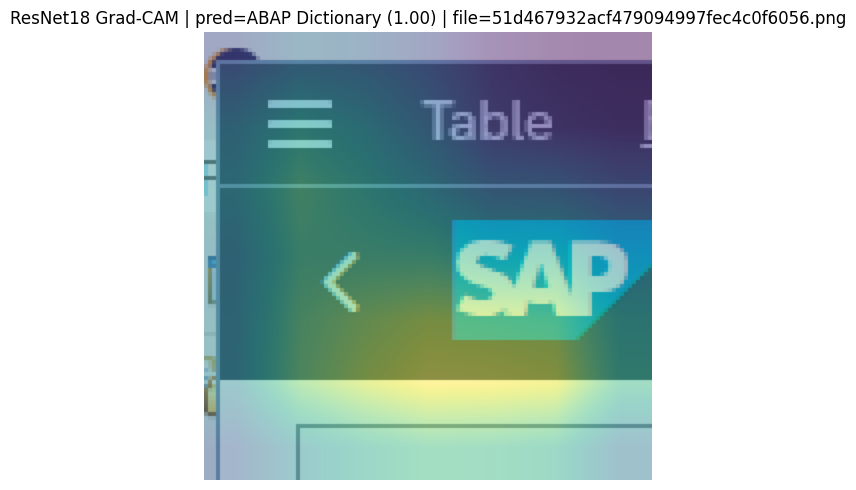

In [90]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# 1) Helper: Grad-CAM berechnen
def gradcam_resnet18(model, input_tensor, target_layer):
    """
    input_tensor: shape (1,3,H,W), already normalized
    target_layer: e.g. model.layer4[-1]
    returns: cam as numpy array (H,W) in [0,1]
    """
    model.eval()

    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    input_tensor = input_tensor.requires_grad_(True)
    logits = model(input_tensor)
    pred_idx = int(logits.argmax(dim=1).item())

    model.zero_grad(set_to_none=True)
    score = logits[0, pred_idx]
    score.backward()

    # Hooks entfernen
    h1.remove()
    h2.remove()

    act = activations[0]          # (1,C,h,w)
    grad = gradients[0]           # (1,C,h,w)

    # Global Average Pooling über Gradients -> weights pro Kanal
    weights = grad.mean(dim=(2,3), keepdim=True)  # (1,C,1,1)
    cam = (weights * act).sum(dim=1, keepdim=True)  # (1,1,h,w)
    cam = torch.relu(cam)

    # Auf Input-Größe hochskalieren
    cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0,0].detach().cpu().numpy()

    # Normalisieren auf [0,1]
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, pred_idx, float(torch.softmax(logits, dim=1)[0, pred_idx].item())


# 2) Helper: Overlay plotten
def show_gradcam_on_image(img_pil, cam, title="Grad-CAM", alpha=0.45):
    """
    img_pil: PIL RGB, cam: (H,W) [0,1]
    """
    img = np.array(img_pil.convert("RGB"))
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.imshow(cam, alpha=alpha)   # Standard-Colormap
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# 3) Beispiel: ein Bild aus VAL erklären
#    Du kannst hier einen konkreten Pfad einsetzen:
# img_path = Path("..") / "Work" / "datasets" / "base_split" / "val" / "Excel" / "xyz.png"

img_path = val_paths[0]  # z.B. erstes Val-Bild; val_paths kommt aus dem Vergleichscode
img_pil = Image.open(img_path).convert("RGB")

# WICHTIG: dieselbe Preprocessing-Transform wie in deiner Val-Evaluation verwenden
x = val_tf(img_pil).unsqueeze(0).to(device)  # val_tf aus deinem ResNet-Setup

# Target Layer: bei ResNet18 meist layer4[-1] (letzter Block)
cam, pred_idx, pred_conf = gradcam_resnet18(model.to(device), x, target_layer=model.layer4[-1])

pred_class = class_names[pred_idx]
title = f"ResNet18 Grad-CAM | pred={pred_class} ({pred_conf:.2f}) | file={Path(img_path).name}"

print("File:", img_path)
print("Pred:", pred_class, "conf:", pred_conf)
show_gradcam_on_image(img_pil, cam, title=title, alpha=0.45)

Misclassified: 5


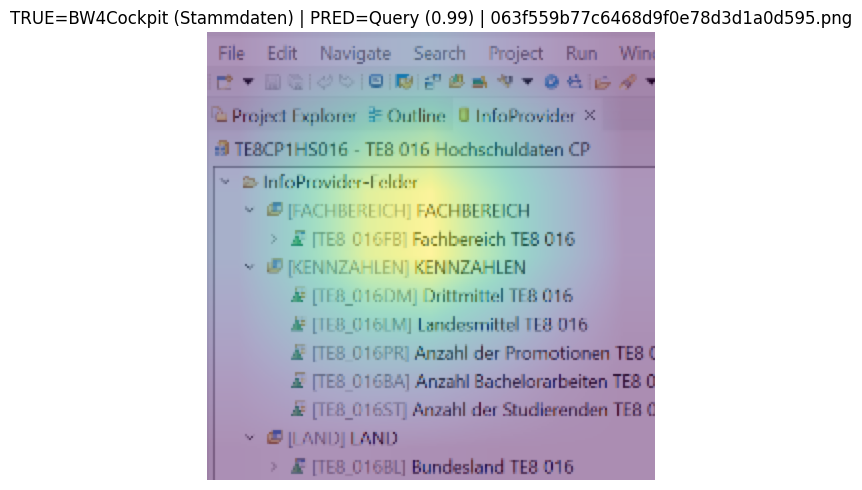

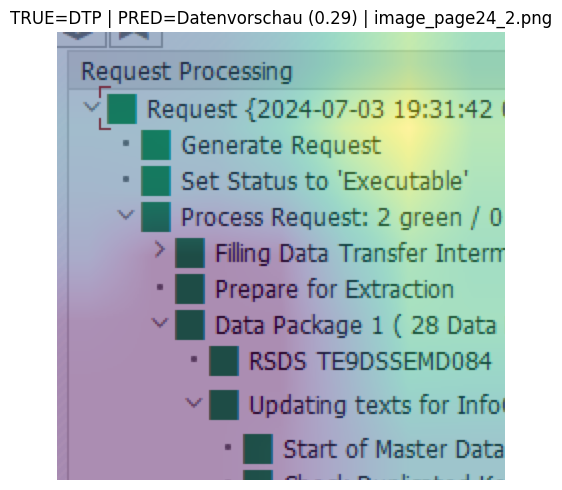

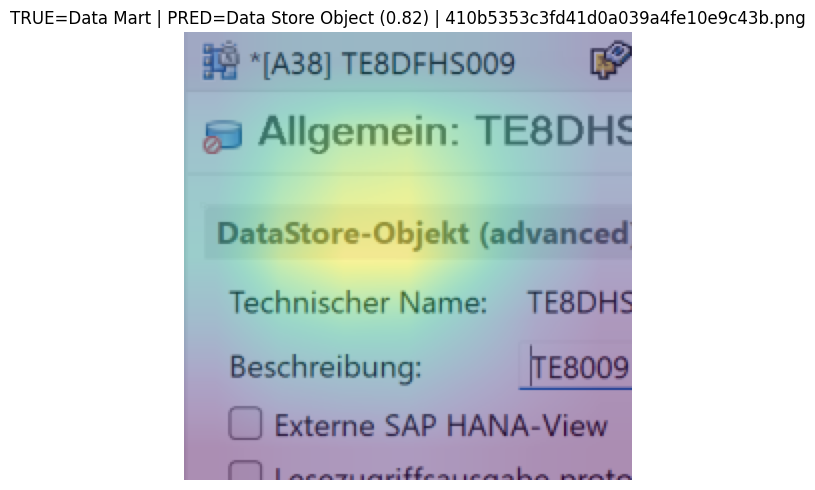

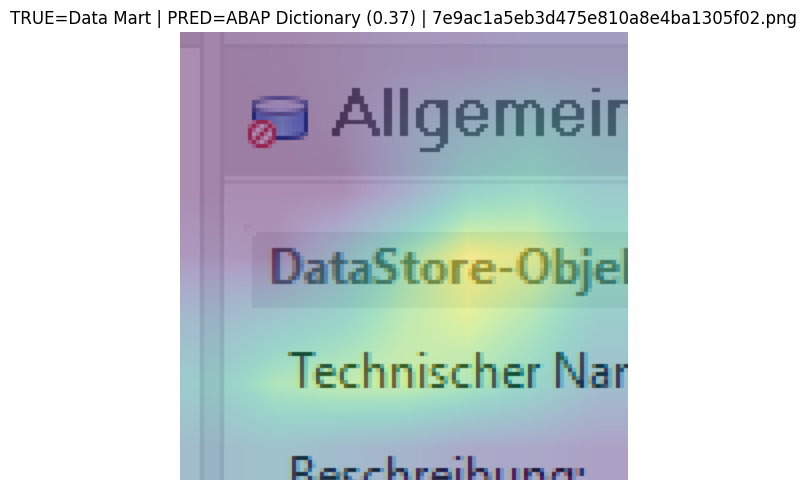

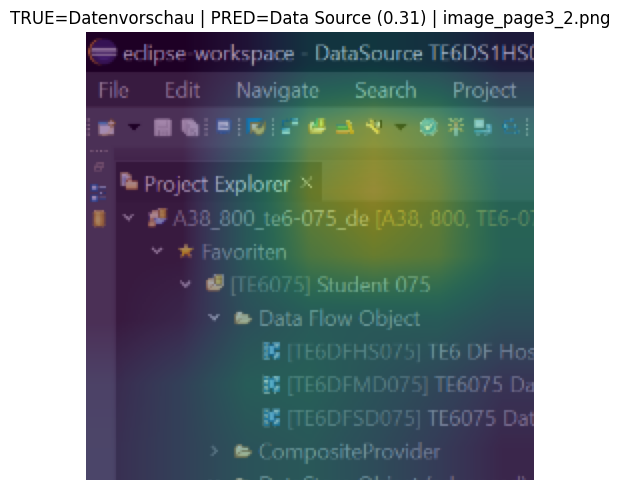

In [91]:
# Fehlklassifikationen finden (setzt voraus, dass du y_true/y_pred schon hast)
# z.B. nach: y_true, y_pred, acc = eval_model(model, val_loader)

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified:", len(mis_idx))

# Zeige z.B. 5 Fehlklassifikationen mit Grad-CAM
for k in mis_idx[:5]:
    # Du brauchst hier eine Zuordnung index->Pfad; am einfachsten: nutze val_paths/y_true_val aus der Val-Paths-Funktion
    # Falls du eval_model(val_loader) nutzt, ist die Reihenfolge identisch zu val_ds.samples (ImageFolder).
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true[k])
    pred_idx = int(y_pred[k])

    img_pil = Image.open(img_path).convert("RGB")
    x = val_tf(img_pil).unsqueeze(0).to(device)

    cam, pidx, pconf = gradcam_resnet18(model.to(device), x, target_layer=model.layer4[-1])

    title = f"TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({pconf:.2f}) | {img_path.name}"
    show_gradcam_on_image(img_pil, cam, title=title, alpha=0.45)

In [92]:
model.load_state_dict(torch.load(CKPT, map_location=device))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [93]:
import numpy as np
import matplotlib.pyplot as plt

def show_ig_overlay(img_pil, attr_tensor, title, alpha=0.45, q=0.99):
    attr = attr_tensor.squeeze(0).detach().cpu().numpy()
    attr = np.sum(np.abs(attr), axis=0)

    vmax = np.quantile(attr, q)
    if vmax > 0:
        attr = np.clip(attr / vmax, 0, 1)

    img = np.array(img_pil.convert("RGB").resize((attr.shape[1], attr.shape[0])))

    plt.figure(figsize=(7,5))
    plt.imshow(img)
    plt.imshow(attr, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [94]:
from captum.attr import IntegratedGradients, NoiseTunnel
from PIL import Image, ImageFilter
import torch

def ig_resnet_smooth(img_path, n_steps=64, nt_samples=20, stdevs=0.15, use_blur_baseline=True):
    img_pil = Image.open(img_path).convert("RGB")
    x = val_tf(img_pil).unsqueeze(0).to(device)
    x = x.clone().detach().requires_grad_(True)

    with torch.inference_mode(False):
        with torch.enable_grad():
            logits = model(x)
            pred_idx = int(logits.argmax(dim=1).item())
            probs = torch.softmax(logits.detach(), dim=1)[0].cpu().numpy()
            conf = float(probs[pred_idx])

            ig = IntegratedGradients(lambda t: model(t))

            baselines = None
            if use_blur_baseline:
                blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
                baselines = val_tf(blur).unsqueeze(0).to(device)

            nt = NoiseTunnel(ig)
            attr = nt.attribute(
                x,
                baselines=baselines,
                target=pred_idx,
                n_steps=n_steps,
                nt_type="smoothgrad_sq",
                nt_samples=nt_samples,
                stdevs=stdevs
            )

    return img_pil, attr, pred_idx, conf, probs

File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png
Pred: ABAP Dictionary conf=0.999


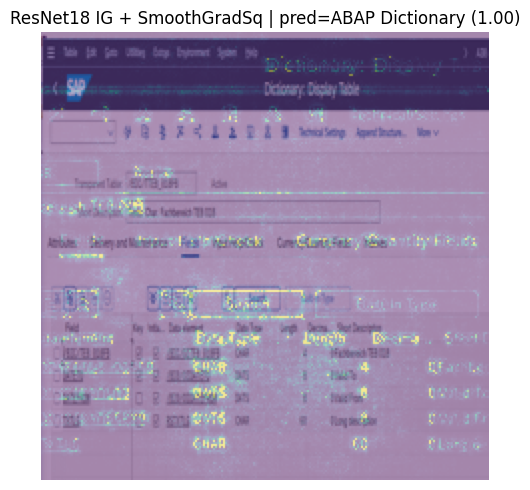

In [95]:
img_path = val_ds.samples[0][0]  # oder irgendein Val-Bild
img_pil, attr, pred_idx, conf, probs = ig_resnet_smooth(img_path)

print("File:", img_path)
print("Pred:", class_names[pred_idx], f"conf={conf:.3f}")
show_ig_overlay(img_pil, attr, f"ResNet18 IG + SmoothGradSq | pred={class_names[pred_idx]} ({conf:.2f})")

In [96]:
from pathlib import Path
from ultralytics import YOLO

# sucht das neueste best.pt unter runs/classify/*
RUNS = Path("runs") / "classify"
best_pts = sorted(RUNS.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)

if not best_pts:
    raise FileNotFoundError("Kein best.pt unter runs/classify gefunden. Prüfe deinen runs-Pfad oder setze den Pfad manuell.")

BEST_PT = best_pts[0]
print("Using:", BEST_PT)

yolo_xai = YOLO(str(BEST_PT))          # frisch geladen
seq = yolo_xai.model.model             # Sequential(...)
device_yolo = next(seq.parameters()).device
seq.eval()

Using: runs\classify\train5\weights\best.pt


Sequential(
  (0): Conv(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C2f(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
          (c

In [97]:
from PIL import Image

def get_yolo_cls_transform(imgsz=224):
    """
    Liefert eine Transform, die ein PIL-Bild -> (3,H,W) Tensor macht.
    Versucht Ultralytics classify_transforms, sonst Fallback auf ImageNet-Norm.
    """
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

In [98]:
from pathlib import Path
from ultralytics import YOLO

# Passe ggf. RUNS an, falls bei dir runs unter src/runs liegt:
RUNS = Path("runs") / "classify"
if not RUNS.exists():
    # fallback, falls Notebook in src liegt
    RUNS = Path("src") / "runs" / "classify"

best_pts = sorted(RUNS.rglob("best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if not best_pts:
    raise FileNotFoundError(f"Kein best.pt gefunden unter: {RUNS}")

BEST_PT = best_pts[0]
print("Using YOLO best.pt:", BEST_PT)

yolo_xai = YOLO(str(BEST_PT))        # frisch geladen
seq = yolo_xai.model.model           # Sequential(...)
device_yolo = next(seq.parameters()).device
seq.eval()

# Mapping idx -> class name
names = yolo_xai.names
idx_to_name = {int(k): v for k, v in names.items()} if isinstance(names, dict) else {i:n for i,n in enumerate(names)}

Using YOLO best.pt: runs\classify\train5\weights\best.pt


In [99]:
def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

tf_yolo = get_yolo_cls_transform(224)

In [100]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from captum.attr import IntegratedGradients, NoiseTunnel

def yolo_forward(x):
    out = seq(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def show_ig_overlay(img_pil, attr_tensor, title, alpha=0.45, q=0.99):
    attr = attr_tensor.squeeze(0).detach().cpu().numpy()   # (3,H,W)
    attr = np.sum(np.abs(attr), axis=0)                    # (H,W)

    vmax = np.quantile(attr, q)
    if vmax > 0:
        attr = np.clip(attr / vmax, 0, 1)

    img = np.array(img_pil.convert("RGB").resize((attr.shape[1], attr.shape[0])))

    plt.figure(figsize=(7,5))
    plt.imshow(img)
    plt.imshow(attr, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def ig_yolo_smooth(img_path, imgsz=224, n_steps=64, nt_samples=20, stdevs=0.15, use_blur_baseline=True):
    img_pil = Image.open(img_path).convert("RGB")

    x = tf_yolo(img_pil).unsqueeze(0).to(device_yolo)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = tf_yolo(blur).unsqueeze(0).to(device_yolo)

    with torch.inference_mode(False):
        with torch.enable_grad():
            logits = yolo_forward(x)
            pred_idx = int(logits.argmax(dim=1).item())

            ig = IntegratedGradients(yolo_forward)
            nt = NoiseTunnel(ig)

            attr = nt.attribute(
                x,
                baselines=baselines,
                target=pred_idx,
                n_steps=n_steps,
                nt_type="smoothgrad_sq",
                nt_samples=nt_samples,
                stdevs=stdevs
            )

            probs = torch.softmax(logits.detach(), dim=1)[0].cpu().numpy()
            conf = float(probs[pred_idx])

    return img_pil, attr, pred_idx, conf, probs

File: ..\Work\datasets\base_split\val\ABAP Dictionary\51d467932acf479094997fec4c0f6056.png
Pred: ABAP Dictionary conf=0.184


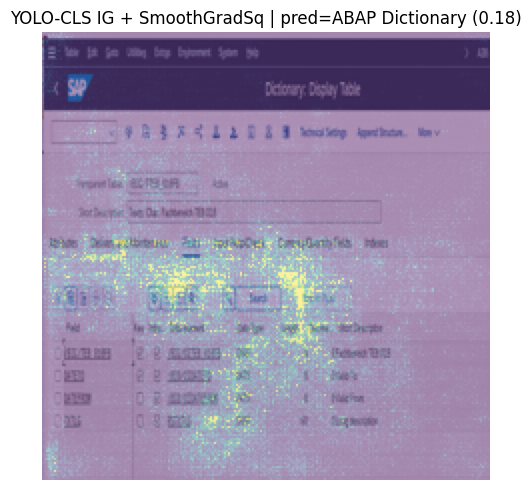

In [101]:
# img_path aus deinem Val-Set:
img_path = val_paths[0] if "val_paths" in globals() else val_ds.samples[0][0]

img_pil, attr, pred_idx, conf, probs = ig_yolo_smooth(
    img_path,
    n_steps=64,
    nt_samples=20,
    stdevs=0.15,
    use_blur_baseline=True
)

pred_name = idx_to_name.get(pred_idx, str(pred_idx))
print("File:", img_path)
print("Pred:", pred_name, f"conf={conf:.3f}")

show_ig_overlay(img_pil, attr, f"YOLO-CLS IG + SmoothGradSq | pred={pred_name} ({conf:.2f})", alpha=0.45, q=0.99)